#Loading and Inspecting the data

In [ ]:
import pandas as pd

In [ ]:
# Here, I am loading the data
data = pd.read_csv("/content/greendestination (1)(1).csv")

In [ ]:
# Here I am seeing the first few rows of the dataframe
print(data.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [ ]:
#Here I am displaying the information about the dataframe
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

#Calculate Attrition Rate

In [ ]:
# Here I calculated the total number of employees and employees who have left
total_employees = data['Attrition'].count()
employees_left = data[data['Attrition'] == 'Yes'].shape[0]

In [ ]:
print(total_employees)

1470


In [ ]:
print(employees_left)

237


In [ ]:
# Here, I calculated the attrition rate
attrition_rate = (employees_left / total_employees) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


#Visualize Key Factors

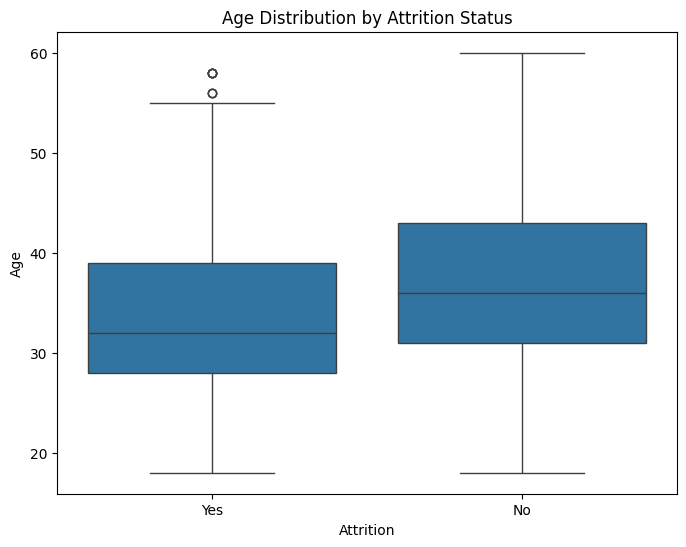

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Here I created a boxplot for Age distribution by Attrition
plt.figure(figsize=(8,6))
sns.boxplot(x='Attrition', y='Age', data=data)
plt.title('Age Distribution by Attrition Status')
plt.show()

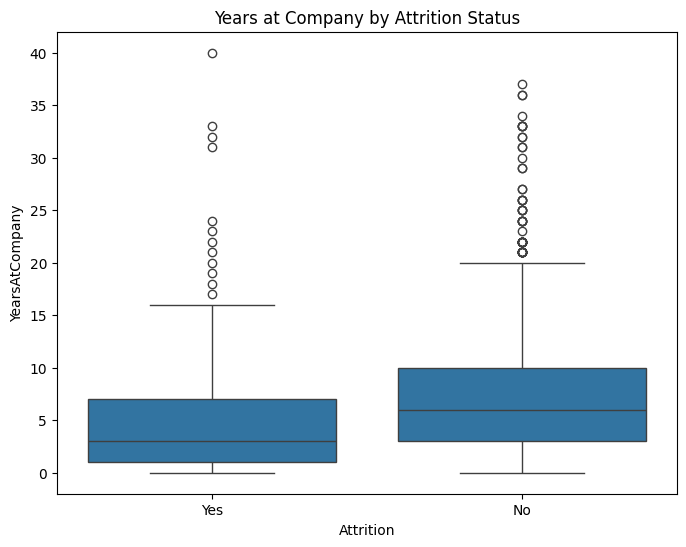

In [ ]:
# Here, I created a boxplot for years at company by attrition
plt.figure(figsize=(8,6))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=data)
plt.title('Years at Company by Attrition Status')
plt.show()

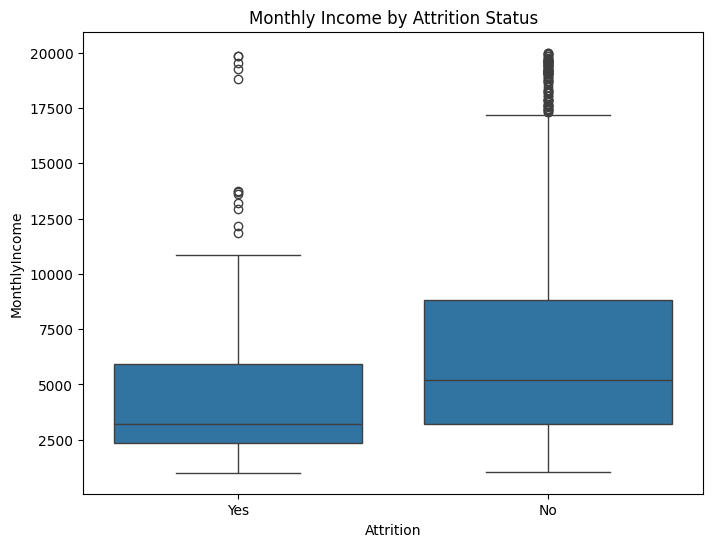

In [ ]:
# Here I created a boxplot for monthly nncome by attrition
plt.figure(figsize=(8,6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data)
plt.title('Monthly Income by Attrition Status')
plt.show()


#Correlation Analysis

In [ ]:
# Here, I converted attrition column to binary for correlation analysis (Yes = 1, No = 0)
data['AttritionBinary'] = data['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

In [ ]:
# Here, I checked the correlation with key factors
correlation_factors = ['Age', 'YearsAtCompany', 'MonthlyIncome', 'AttritionBinary']
correlation = data[correlation_factors].corr()

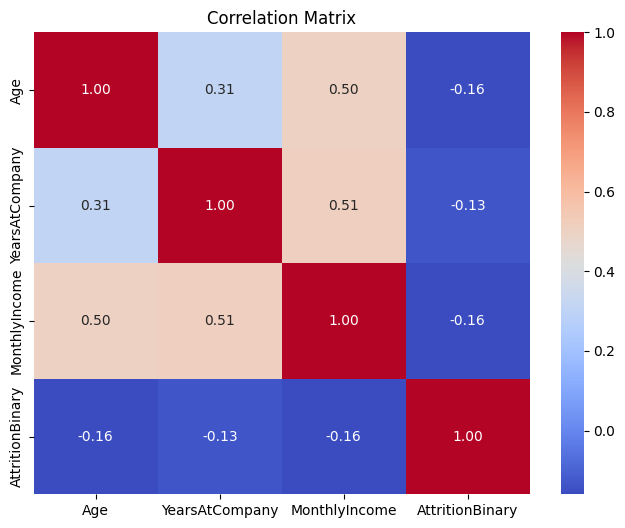

In [ ]:
# Here, I visualized the correlation matrix using a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

#Logistic Regression Model
Build and evaluate a logistic regression model to predict attrition.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Here, I selected the relevant features and target
X = data[['Age', 'YearsAtCompany', 'MonthlyIncome']]
y = data['AttritionBinary']

# Here, I split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Here, I applied SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Here, I standardized the features
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

# Here, I initialized and train the logistic regression model with regularization
model = LogisticRegression(C=1.0, penalty='l2', solver='liblinear', random_state=42)
model.fit(X_train_res, y_train_res)

# Here, I made predictions on the test set
y_pred = model.predict(X_test)

# Here I printed the report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.59      0.72       380
           1       0.19      0.57      0.28        61

    accuracy                           0.59       441
   macro avg       0.54      0.58      0.50       441
weighted avg       0.80      0.59      0.65       441

